# N1 · 给一个子领域建引用网 + 找奠基/前沿 (Build Citation Graph)

> 配套 9.2-L2 · **真实科研动作**: 把「偏好优化」子领域的论文 + 引用关系建成网络,
> 用 PageRank 中心度**自动**区分「必读奠基作」与「可跳过的边缘工作」, 并亲眼验证
> 「中心度相对采样集」这个 caveat。

不训练任何模型。做的是研究者摸新领域第一周必做的事: 把文献从「列表」变成「网」。

In [1]:
import sys
from pathlib import Path
import pandas as pd
SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import snowball as sb
net = sb.load_sample_net()
print(f"偏好优化子领域: {net.number_of_nodes()} 篇, {net.number_of_edges()} 条引用边")

偏好优化子领域: 12 篇, 19 条引用边


## 1. PageRank 中心度: 谁最奠基 (被很多重要论文引 = 重要)

In [2]:
cen = sb.centrality(net)
df = pd.DataFrame([{
    "PageRank": c["pagerank"], "被引": c["cited_by"],
    "论文": c["name"], "年份": c["year"], "流派": c["family"],
} for c in cen])
df

,PageRank,被引,论文,年份,流派
0,0.1223,3,InstructGPT (RLHF),2022,RLHF 经典
1,0.1083,6,DPO,2023,直接偏好优化
2,0.0992,0,Iterative/Online DPO,2024,在线化
3,0.0980,0,SimPO (reference-free),2024,直接偏好优化
4,0.0980,0,Robust-DPO (噪声偏好),2024,鲁棒性
5,0.0944,0,DeepSeek-R1 (RL for reasoning),2025,推理 RL
6,0.0785,2,IPO,2023,直接偏好优化
7,0.0737,1,Learning to summarize from HF,2020,RLHF 早期
8,0.0646,0,KTO,2024,直接偏好优化
9,0.0646,0,ORPO,2024,直接偏好优化


## 2. 奠基作 vs 前沿作

- **奠基作** (入度最高): 你摸领域必须先读的「肩膀」。
- **前沿作** (年份最新): 找 gap 的前线 (交棒 9.3)。

In [3]:
print("📚 奠基作 (必读肩膀):")
for p in sb.seminal_papers(net, 3):
    print(f"   · {p['name']} ({p['year']})  被引 {p['cited_by']}")
print("\n🔭 前沿作 (找 gap 前线):")
for p in sb.frontier_papers(net, 3):
    print(f"   · {p['name']} ({p['year']})")

📚 奠基作 (必读肩膀):
   · DPO (2023)  被引 6
   · PPO (2017)  被引 4
   · Bradley-Terry 偏好模型 (1952)  被引 3

🔭 前沿作 (找 gap 前线):
   · DeepSeek-R1 (RL for reasoning) (2025)
   · KTO (2024)
   · ORPO (2024)


## 3. caveat 验证: 中心度是「相对采样集」的 (L2 §5)

在这个**偏好优化滚雪球集合**里, DPO 的 PageRank/入度最高 —— 因为 KTO/ORPO/SimPO/IPO 都引它。
但 PPO 在整个 RL 领域显然更奠基。下面用数字坐实这个 caveat: 在我们框定的集合内, 谁引了 DPO、谁引了 PPO。

In [4]:
for pid in ["dpo2023", "ppo2017"]:
    name = net.nodes[pid]["name"]
    citers = [net.nodes[c]["name"] for c in net.predecessors(pid)]
    print(f"{name}: 在本集合内被 {len(citers)} 篇引 → {citers}")
print("\n结论: DPO 在'偏好优化'这片采样里最中心; 换一片采样(整个RL), PPO会更中心。")
print("→ 写 mini-survey 时务必诚实交代你框定的范围 (L2 caveat)。")

DPO: 在本集合内被 6 篇引 → ['IPO', 'KTO', 'ORPO', 'SimPO (reference-free)', 'Robust-DPO (噪声偏好)', 'Iterative/Online DPO']
PPO: 在本集合内被 4 篇引 → ['Learning to summarize from HF', 'InstructGPT (RLHF)', 'DPO', 'DeepSeek-R1 (RL for reasoning)']

结论: DPO 在'偏好优化'这片采样里最中心; 换一片采样(整个RL), PPO会更中心。
→ 写 mini-survey 时务必诚实交代你框定的范围 (L2 caveat)。


## 4. 画引用网 (节点越大=被引越多=越奠基, 颜色=流派)

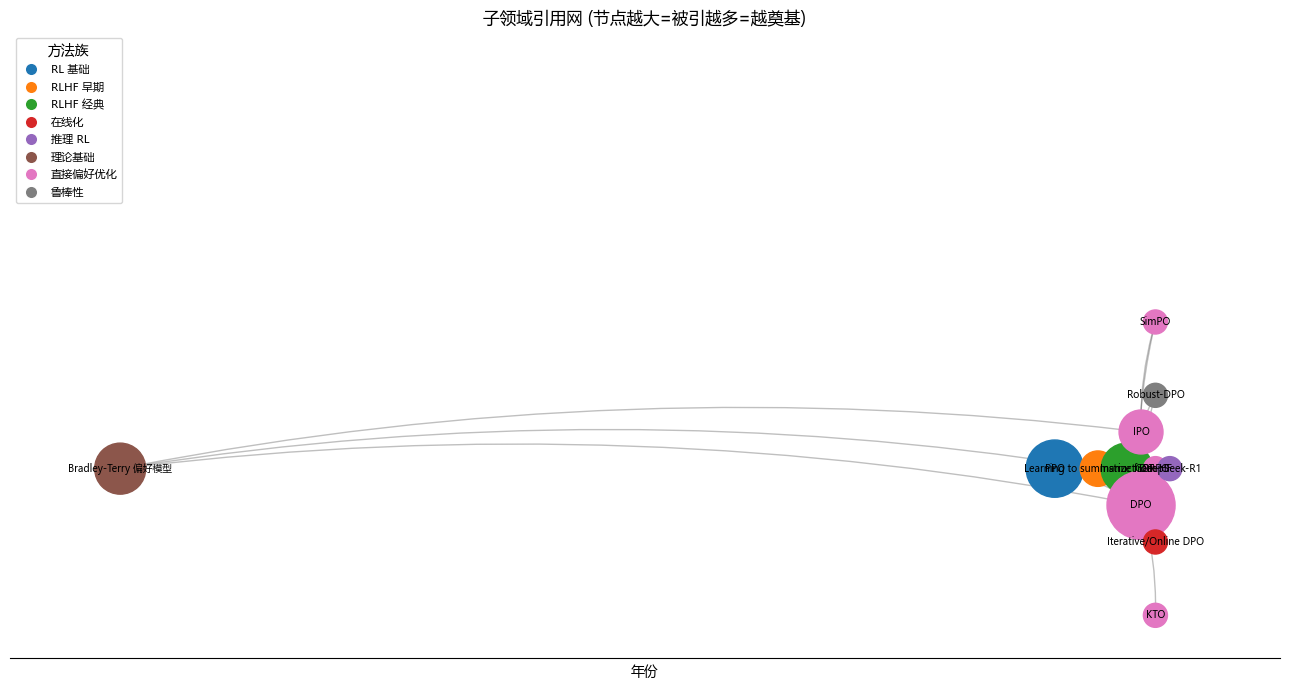

In [5]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus'] = False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try:
        matplotlib.rcParams['font.sans-serif'] = [f]; break
    except Exception:
        pass
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(13, 7))
sb.plot_net(net, ax=ax)
plt.tight_layout()
plt.show()

## 5. 反思

你刚把一个子领域从「一堆论文」变成了「一张能读拓扑的网」, 并用 PageRank 把「先读哪篇」从
主观判断变成了**排序**。这就是 L1 说的「摸领域产出结构, 不是摘要堆叠」。

**真用时怎么换成你的领域**: `snowball.py` 的 `PAPERS`/`EDGES` 是手工录入的离线样例。
真实做法是用 Semantic Scholar API 把一个种子论文的 references+citations 拉下来自动建网
(见 9.3 的 `citation_graph.fetch_paper_graph`, 同源思路)。本 notebook 用离线集是为了
**任何环境都能跑通 + 结果可复现**。

下一步: 去 N2 把这张网整理成带流派和演进线的**领域地图**。